# Выпускной проект "Телеком"

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. Ваша задача — обучить на этих данных модель для прогноза оттока клиентов.

## Описание услуг

Оператор предоставляет два основных типа услуг:
Стационарную телефонную связь. Телефон можно подключить к нескольким линиям одновременно.
Интернет. Подключение бывает двух типов: через телефонную линию DSL (англ. digital subscriber line — «цифровая абонентская линия») или оптоволоконный кабель (англ. fiber optic).

Также абонентам доступен ряд услуг:
- Интернет-безопасность: антивирус (Device Protection) и блокировка опасных сайтов (Online Security);
- Выделенная линия технической поддержки (Tech Support);
- Облачное хранилище файлов для резервного копирования данных (Online Backup);
- Стриминговое телевидение (Streaming TV) и каталог фильмов (Streaming Movies).

За услуги клиенты могут платить ежемесячно или раз в 1–2 года. Доступны различные способы расчёта и возможность получить электронный чек.


## Описание данных

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:

contract — информация о договорах;
personal — персональные данные клиентов;
internet — информация об интернет-услугах;
phone — информация об услугах телефонии.

### Таблица contract
customerID — ID абонента;
BeginDate — дата начала действия договора;
EndDate — дата окончания действия договора;
Type — тип оплаты: раз в год-два или ежемесячно;
PaperlessBilling — электронный расчётный лист;
PaymentMethod — тип платежа;
MonthlyCharges — расходы за месяц;
TotalCharges — общие расходы абонента.

### Таблица personal
customerID — ID пользователя;
gender — пол;
SeniorCitizen — является ли абонент пенсионером;
Partner — есть ли у абонента супруг или супруга;
Dependents — есть ли у абонента дети.

### Таблица internet
customerID — ID пользователя;
InternetService — тип подключения;
OnlineSecurity — блокировка опасных сайтов;
OnlineBackup — облачное хранилище файлов для резервного копирования данных;
DeviceProtection — антивирус;
TechSupport — выделенная линия технической поддержки;
StreamingTV — стриминговое телевидение;
StreamingMovies — каталог фильмов.

### Таблица phone
customerID — ID пользователя;
MultipleLines — подключение телефона к нескольким линиям одновременно.

Информация о договорах актуальна на 1 февраля 2020.

## Загрузка данных

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder 
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, make_scorer, precision_score, roc_curve, auc
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoost, CatBoostClassifier, Pool
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline 
from imblearn.over_sampling import SMOTE 
from catboost import CatBoostClassifier 
from lightgbm import LGBMClassifier
import phik
from phik.report import plot_correlation_matrix
import seaborn as sns
from matplotlib import pyplot as plt
from pandas.plotting import scatter_matrix
import os
from sqlalchemy import create_engine

RANDOM_STATE = 100226
TEST_SIZE = 0.25

In [2]:
def first_check(df, dataset_name=''):
    # Печатаем название датасета (если их несколько)
    if dataset_name:
        print(f'Анализ датасета: {dataset_name}')
    else:
        print('Анализ датасета')
    print("=" * 40 + "\n")

    print('Первые 5 строк:')
    display(df.head())
    print('\nПоледние 5 строк:')
    display(df.tail())
    print('\nРазмерность датасета:')
    print(df.shape)

    print('\nИнформаци о данных')
    print(df.info())

    print('\nОписательная статистика:')
    display(df.describe(include='all'))

    print('\nНаличие пропусков и дублей:')
    display(df.duplicated().sum())

def result_met(name, roc_auc, precision):
    result.loc[name, ['ROC_AUC']] = roc_auc
    result.loc[name, ['Precision']] = precision
    return result

In [3]:
path_to_db = '/kaggle/input/database/ds-plus-final.db'
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

In [4]:
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query, engine)

print("Таблицы в базе данных:")
print(tables)

Таблицы в базе данных:
              name
0         data_arc
1        data_bulk
2   data_bulk_time
3   data_wire_time
4         contract
5         personal
6            phone
7         internet
8         data_gas
9        data_temp
10       data_wire


In [5]:
print("\nКоличество записей в таблицах:")
for table_name in tables['name']:
    count_query = f"SELECT COUNT(*) as count FROM {table_name}"
    count_result = pd.read_sql_query(count_query, engine)
    print(f"{table_name}: {count_result['count'].iloc[0]} записей")


Количество записей в таблицах:
data_arc: 14876 записей
data_bulk: 3129 записей
data_bulk_time: 3129 записей
data_wire_time: 3081 записей
contract: 7043 записей
personal: 7043 записей
phone: 6361 записей
internet: 5517 записей
data_gas: 3239 записей
data_temp: 18092 записей
data_wire: 3081 записей


In [6]:
def load_table(table_name, engine, save_to_file=True, file_format='parquet'):
    print(f"Загружаем таблицу: {table_name}")
    
    # Загружаем данные из БД
    query = f"SELECT * FROM {table_name}"
    df = pd.read_sql_query(query, engine)
    
    # Сохраняем в файл, если требуется
    if save_to_file:
        if file_format == 'parquet':
            filename = f"{table_name}.parquet"
            df.to_parquet(filename, index=False)
        elif file_format == 'csv':
            filename = f"{table_name}.csv"
            df.to_csv(filename, index=False)
        elif file_format == 'pickle':
            filename = f"{table_name}.pkl"
            df.to_pickle(filename)
        
        print(f"Таблица сохранена в файл: {filename}")
        print(f"Размер файла: {os.path.getsize(filename) / 1024:.2f} KB")
    
    print(f"Загружено {len(df)} записей")
    print(f"Колонки: {list(df.columns)}")
    print("-" * 50)
    
    return df

def load_from_file(table_name, file_format='parquet'):
    if file_format == 'parquet':
        filename = f"{table_name}.parquet"
    elif file_format == 'csv':
        filename = f"{table_name}.csv"
    elif file_format == 'pickle':
        filename = f"{table_name}.pkl"
    
    if os.path.exists(filename):
        print(f"Загружаем таблицу {table_name} из файла {filename}")
        
        if file_format == 'parquet':
            df = pd.read_parquet(filename)
        elif file_format == 'csv':
            df = pd.read_csv(filename)
        elif file_format == 'pickle':
            df = pd.read_pickle(filename)
        
        print(f"Загружено {len(df)} записей")
        print(f"Колонки: {list(df.columns)}")
        print("-" * 50)
        return df
    else:
        print(f"Файл {filename} не найден")
        return None

In [7]:
FILE_FORMAT = 'csv'

# Основные таблицы из описания
main_tables = ['contract', 'personal', 'internet', 'phone']

# Проверяем, какие таблицы существуют в базе
available_tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", 
    engine
)['name'].tolist()

print(f"Доступные таблицы: {available_tables}")

# Загружаем только те таблицы, которые есть в базе
tables_to_load = [table for table in main_tables if table in available_tables]

# Словарь для хранения DataFrame
dataframes = {}

for table in tables_to_load:
    df = load_table(table, engine, save_to_file=True, file_format=FILE_FORMAT)
    dataframes[table] = df


Доступные таблицы: ['data_arc', 'data_bulk', 'data_bulk_time', 'data_wire_time', 'contract', 'personal', 'phone', 'internet', 'data_gas', 'data_temp', 'data_wire']
Загружаем таблицу: contract
Таблица сохранена в файл: contract.csv
Размер файла: 511.90 KB
Загружено 7043 записей
Колонки: ['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
--------------------------------------------------
Загружаем таблицу: personal
Таблица сохранена в файл: personal.csv
Размер файла: 177.32 KB
Загружено 7043 записей
Колонки: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents']
--------------------------------------------------
Загружаем таблицу: internet
Таблица сохранена в файл: internet.csv
Размер файла: 216.11 KB
Загружено 5517 записей
Колонки: ['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
-------------------------------------------

In [8]:
if 'engine' in locals():
    engine.dispose()
    print("Соединение с базой данных закрыто")

if 'connection' in locals():
    connection.close()
    print("Соединение закрыто")

Соединение с базой данных закрыто


In [9]:
contract = pd.read_csv('/kaggle/working/contract.csv')
personal = pd.read_csv('/kaggle/working/personal.csv')
internet = pd.read_csv('/kaggle/working/internet.csv')
phone = pd.read_csv('/kaggle/working/phone.csv')

In [10]:
first_check(contract)

Анализ датасета

Первые 5 строк:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1960.6
4,9237-HQITU,2019-09-01,No,Month-to-month,Yes,Electronic check,70.70,353.5



Поледние 5 строк:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,2035.2
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7430.4
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,325.6
7041,8361-LTMKD,2019-07-01,No,Month-to-month,Yes,Mailed check,74.40,520.8
7042,3186-AJIEK,2014-08-01,No,Two year,Yes,Bank transfer (automatic),105.65,7251.82



Размерность датасета:
(7043, 8)

Информаци о данных
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
None

Описательная статистика:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
count,7043,7043,7043,7043,7043,7043,7043.000000,7043
unique,7043,77,67,3,2,4,NaN,6658
top,3186-AJIEK,2014-02-01,No,Month-to-month,Yes,Electronic check,NaN,
freq,1,366,5942,3875,4171,2365,NaN,11
mean,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN



Наличие пропусков и дублей:


np.int64(0)

In [11]:
first_check(personal)

Анализ датасета

Первые 5 строк:


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No



Поледние 5 строк:


,customerID,gender,SeniorCitizen,Partner,Dependents
7038,6840-RESVB,Male,0,Yes,Yes
7039,2234-XADUH,Female,0,Yes,Yes
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No
7042,3186-AJIEK,Male,0,No,No



Размерность датасета:
(7043, 5)

Информаци о данных
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB
None

Описательная статистика:


,customerID,gender,SeniorCitizen,Partner,Dependents
count,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2
top,3186-AJIEK,Male,NaN,No,No
freq,1,3555,NaN,3641,4933
mean,NaN,NaN,0.162147,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN



Наличие пропусков и дублей:


np.int64(0)

In [12]:
first_check(internet)

Анализ датасета

Первые 5 строк:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No



Поледние 5 строк:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
5512,6840-RESVB,DSL,Yes,No,Yes,Yes,Yes,Yes
5513,2234-XADUH,Fiber optic,No,Yes,Yes,No,Yes,Yes
5514,4801-JZAZL,DSL,Yes,No,No,No,No,No
5515,8361-LTMKD,Fiber optic,No,No,No,No,No,No
5516,3186-AJIEK,Fiber optic,Yes,No,Yes,Yes,Yes,Yes



Размерность датасета:
(5517, 8)

Информаци о данных
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB
None

Описательная статистика:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
count,5517,5517,5517,5517,5517,5517,5517,5517
unique,5517,2,2,2,2,2,2,2
top,3186-AJIEK,Fiber optic,No,No,No,No,No,No
freq,1,3096,3498,3088,3095,3473,2810,2785



Наличие пропусков и дублей:


np.int64(0)

In [13]:
first_check(phone)

Анализ датасета

Первые 5 строк:


,CustomerId,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes



Поледние 5 строк:


,CustomerId,MultipleLines
6356,2569-WGERO,No
6357,6840-RESVB,Yes
6358,2234-XADUH,Yes
6359,8361-LTMKD,Yes
6360,3186-AJIEK,No



Размерность датасета:
(6361, 2)

Информаци о данных
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerId     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB
None

Описательная статистика:


,CustomerId,MultipleLines
count,6361,6361
unique,6361,2
top,3186-AJIEK,No
freq,1,3390



Наличие пропусков и дублей:


np.int64(0)

### Вывод:

Загрузили файлы с данными; Пропусков и дублей не зафиксированы. По части пользователей отсутствуют данные, уберем таких пользователей.

### Предобработка данных

In [14]:
phone.rename(columns={'CustomerId': 'customerID'}, inplace=True)

In [15]:
df = contract.merge(personal, on='customerID', how='inner')
df = df.merge(internet, on ='customerID', how = 'outer')
df = df.merge(phone, on ='customerID', how = 'outer')

display(df.head())
df.info()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,0002-ORFBO,2019-05-01,No,One year,Yes,Mailed check,65.6,631.73,Female,0,Yes,Yes,DSL,No,Yes,No,Yes,Yes,No,No
1,0003-MKNFE,2019-05-01,No,Month-to-month,No,Mailed check,59.9,539.1,Male,0,No,No,DSL,No,No,No,No,No,Yes,Yes
2,0004-TLHLJ,2019-09-01,No,Month-to-month,Yes,Electronic check,73.9,406.45,Male,0,No,No,Fiber optic,No,No,Yes,No,No,No,No
3,0011-IGKFF,2018-12-01,No,Month-to-month,Yes,Electronic check,98.0,1372.0,Male,1,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,No
4,0013-EXCHZ,2019-09-01,No,Month-to-month,Yes,Mailed check,83.9,444.67,Female,1,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


In [16]:
print('Количество дубликатов:', df.duplicated().sum())

Количество дубликатов: 0


In [17]:
for i in df.columns:
    print(f'Признак "{i}" имеет {len(df[i].unique())} уникальных значений:')
    print(df[i].unique(), '\n')

Признак "customerID" имеет 7043 уникальных значений:
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH'] 

Признак "BeginDate" имеет 77 уникальных значений:
['2019-05-01' '2019-09-01' '2018-12-01' '2014-03-01' '2014-11-01'
 '2019-07-01' '2014-09-01' '2015-08-01' '2014-02-01' '2015-06-01'
 '2017-04-01' '2020-01-01' '2016-03-01' '2019-10-01' '2015-12-01'
 '2018-10-01' '2018-03-01' '2019-11-01' '2015-07-01' '2017-12-01'
 '2014-05-01' '2017-01-01' '2016-01-01' '2014-08-01' '2014-07-01'
 '2018-06-01' '2016-07-01' '2015-03-01' '2019-02-01' '2017-11-01'
 '2018-01-01' '2017-09-01' '2017-03-01' '2014-10-01' '2016-11-01'
 '2016-10-01' '2016-09-01' '2019-08-01' '2017-08-01' '2014-04-01'
 '2015-05-01' '2015-04-01' '2017-06-01' '2015-10-01' '2017-05-01'
 '2019-04-01' '2018-02-01' '2015-01-01' '2018-07-01' '2016-06-01'
 '2018-11-01' '2019-12-01' '2014-12-01' '2019-03-01' '2019-06-01'
 '2014-01-01' '2016-04-01' '2018-08-01' '2018-04-01' '2015-02-01'
 '2016-02-01' '201

In [18]:
Null_detected = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df[Null_detected] = df[Null_detected].fillna('Unknown')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   7043 non-null   object 
 13  OnlineSecurity    7043 non-null   object 
 14  OnlineBackup      7043 non-null   object 
 15  DeviceProtection  7043 non-null   object 
 16  TechSupport       7043 non-null   object 


Добавим целевой признак в таблицу.

In [19]:
# Функция для преобразования:
def target_maker(row):
    if row['EndDate'] == 'No':
        return 0
    return 1

df['target'] = df.apply(target_maker, axis=1)
df.target.value_counts()

target
0    5942
1    1101
Name: count, dtype: int64

Добавим признак - длительность пользования услуг

In [20]:
df['BeginDate'] = pd.to_datetime(df['BeginDate'], format='%Y-%m-%d')

df['EndDate'] = df.loc[df['EndDate'] == 'No', 'EndDate'] = '2020-02-01'
df['EndDate'] = pd.to_datetime(df['EndDate'], format='%Y-%m-%d')

df['duration_cont'] = (df['EndDate'] - df['BeginDate']).dt.days

In [21]:
del df['BeginDate']
del df['EndDate'] 
del df['customerID']

print('Количество пропусков:', df.isnull().sum())
print('Количество дубликатов:', df.duplicated().sum())

Количество пропусков: Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
target              0
duration_cont       0
dtype: int64
Количество дубликатов: 4


In [22]:
df = df.dropna()
df.drop_duplicates(inplace=True)

print('Количество пропусков:', df.isnull().sum())
print('Количество дубликатов:', df.duplicated().sum())

Количество пропусков: Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
target              0
duration_cont       0
dtype: int64
Количество дубликатов: 0


In [23]:
df['duration_cont'] = df['duration_cont'].astype('int64')
df['SeniorCitizen'] = df['SeniorCitizen'].astype('int64')
df['target'] = df['target'].astype('int64')

In [24]:
# Появилась ошибка на phik, удалим пропуски
def maker(row):
    if row['TotalCharges'] == ' ':
        return None
    return row

df = df.apply(maker, axis=1)

df['TotalCharges'] = df['TotalCharges'].astype('float64')

### Вывод:

Провели предобработку данных в ходе которой:
- Изменили тип данных
- Объединили таблицы
- Удалили лишние признаки
- Добавили новые признаки

### Исследовательский анализ данных

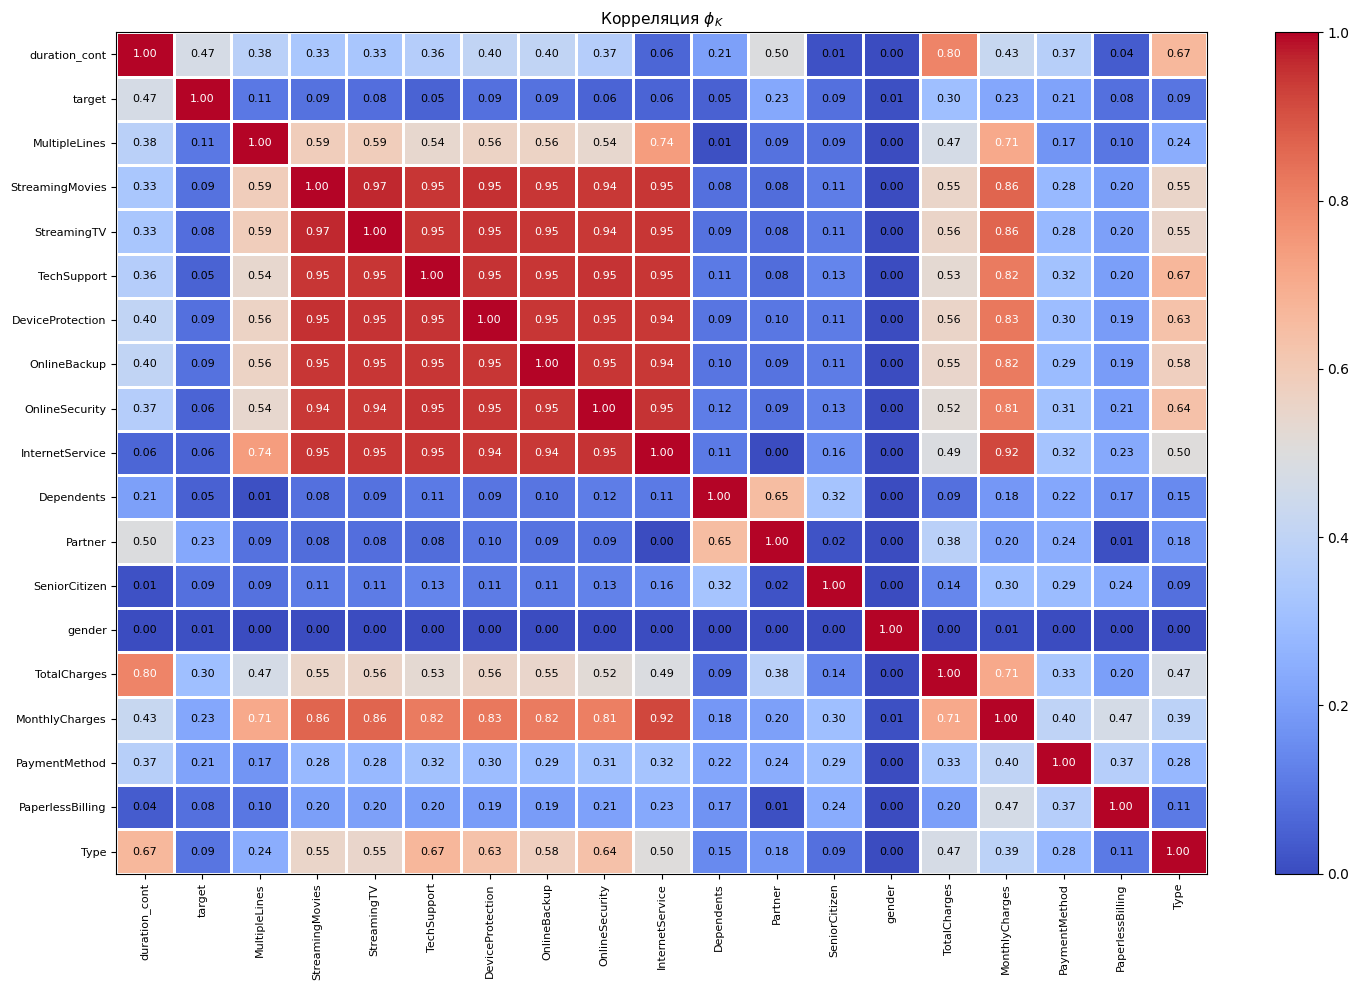

In [25]:
phik_overview = df.phik_matrix(interval_cols=['MonthlyCharges', 'TotalCharges', 'duration_cont'])
phik_overview.round(2)

plot_correlation_matrix(phik_overview.values, 
                        x_labels=phik_overview.columns, 
                        y_labels=phik_overview.index, 
                        vmin=0, vmax=1, color_map="coolwarm", 
                        title=r"Корреляция $\phi_K$", 
                        fontsize_factor=0.8, 
                        figsize=(15, 10))
plt.tight_layout()
plt.show()

Только признаки "duratiohn_cont" и "TotalCharges" имеют значимую связь с целевым признаком.

### Обучение моделей

In [26]:
print(f"Пропуски в df: {df.isna().sum()}")

Пропуски в df: Type                11
PaperlessBilling    11
PaymentMethod       11
MonthlyCharges      11
TotalCharges        11
gender              11
SeniorCitizen       11
Partner             11
Dependents          11
InternetService     11
OnlineSecurity      11
OnlineBackup        11
DeviceProtection    11
TechSupport         11
StreamingTV         11
StreamingMovies     11
MultipleLines       11
target              11
duration_cont       11
dtype: int64


In [27]:
df = df.dropna()

In [28]:
x = df.drop('target', axis=1)
y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = TEST_SIZE, random_state = RANDOM_STATE)

x_test, x_valid, y_test, y_valid = train_test_split(x_test, y_test, test_size= TEST_SIZE, random_state= RANDOM_STATE)

print(x_train.shape, y_train.shape,
      x_valid.shape, y_valid.shape,
      x_test.shape, y_test.shape)

(5271, 18) (5271,) (440, 18) (440,) (1317, 18) (1317,)


In [29]:
num_col = ['MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'duration_cont']
cat_col = ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']

scaler = StandardScaler()
scaler.fit(x_train[num_col])
x_train[num_col] = scaler.transform(x_train[num_col])
x_test[num_col] = scaler.transform(x_test[num_col])
x_valid[num_col] = scaler.transform(x_valid[num_col])

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_col),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_col)
    ])

x_train_processed = preprocessor.fit_transform(x_train)
x_valid_processed = preprocessor.transform(x_valid)
x_test_processed = preprocessor.transform(x_test)

### Обучим модель Random_Forest

In [31]:
model_forest = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100, max_depth=12)
model_forest.fit(x_train_processed, y_train)
pred_proba_forest = model_forest.predict_proba(x_valid_processed)[:, 1]
rf_score = roc_auc_score(y_valid, pred_proba_forest)
print('ROC-AUC: ',rf_score)

ROC-AUC:  0.9295711681969806


### Обучим модель LogisticRegression

In [32]:
model_log = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear')
model_log.fit(x_train_processed, y_train)
pred_proba_log = model_log.predict_proba(x_valid_processed)[:, 1]
lr_score = roc_auc_score(y_valid, pred_proba_log)
print('ROC-AUC: ',lr_score)

ROC-AUC:  0.9452181987000929


### Обучим модель CatBoost

In [33]:
model_cat = CatBoostClassifier(random_state=RANDOM_STATE)
model_cat.fit(x_train_processed, y_train)
pred_proba_cat = model_cat.predict_proba(x_valid_processed)[:, 1]
cb_score = roc_auc_score(y_valid, pred_proba_cat)
print('ROC-AUC: ',cb_score)

Learning rate set to 0.02095
0:	learn: 0.6702458	total: 57.1ms	remaining: 57s
1:	learn: 0.6522445	total: 61.2ms	remaining: 30.5s
2:	learn: 0.6321689	total: 64.3ms	remaining: 21.4s
3:	learn: 0.6133361	total: 67.5ms	remaining: 16.8s
4:	learn: 0.5954296	total: 70.9ms	remaining: 14.1s
5:	learn: 0.5764686	total: 74.7ms	remaining: 12.4s
6:	learn: 0.5611133	total: 78.1ms	remaining: 11.1s
7:	learn: 0.5456527	total: 81.3ms	remaining: 10.1s
8:	learn: 0.5315416	total: 84.4ms	remaining: 9.29s
9:	learn: 0.5182568	total: 87.4ms	remaining: 8.65s
10:	learn: 0.5058771	total: 90.6ms	remaining: 8.15s
11:	learn: 0.4939459	total: 93.8ms	remaining: 7.72s
12:	learn: 0.4835436	total: 97.1ms	remaining: 7.37s
13:	learn: 0.4713418	total: 100ms	remaining: 7.07s
14:	learn: 0.4611821	total: 104ms	remaining: 6.82s
15:	learn: 0.4538309	total: 107ms	remaining: 6.59s
16:	learn: 0.4441818	total: 111ms	remaining: 6.39s
17:	learn: 0.4354107	total: 114ms	remaining: 6.22s
18:	learn: 0.4266200	total: 117ms	remaining: 6.05s
1

In [34]:
table = pd.DataFrame({'Model': ['RandomForestClassifier', 'LogisticRegression', 'CatBoostClassifier'], 'ROC-AUC':[rf_score, lr_score,cb_score]}).sort_values('ROC-AUC', ascending=False)
table

,Model,ROC-AUC
2,CatBoostClassifier,0.969119
1,LogisticRegression,0.945218
0,RandomForestClassifier,0.929571


### Вывод:

В ходе работы было обучено 3 модели: RandomForestClassifier, LogisticRegression и CatBoostClassifier. Наилучший результат показала модель CatBoost. Используем её для тестов.

### Тестирование модели

In [35]:
pred_proba_up = model_cat.predict_proba(x_test_processed)[:, 1]

cb_score = roc_auc_score(y_test, pred_proba_up)
print('ROC-AUC: ',cb_score)

ROC-AUC:  0.9673404641044234


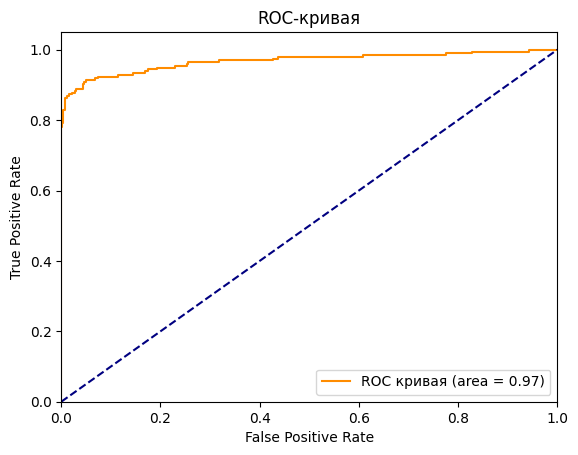

ROC_AUC Метрика:  0.9673404641044234


In [36]:
fpr, tpr, treshold = roc_curve(y_test, pred_proba_up)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange',
         label='ROC кривая (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.show()
print('ROC_AUC Метрика: ',roc_auc_score(y_test, pred_proba_up))

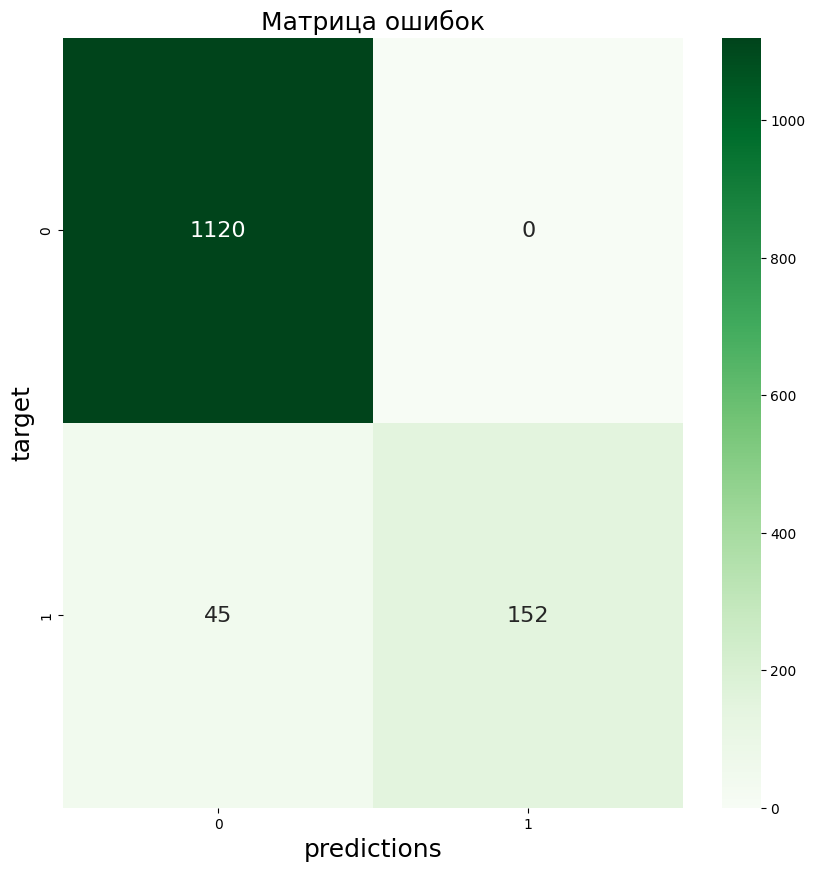

In [38]:
pred_up = model_cat.predict(x_test_processed)

cm_cbc = confusion_matrix(y_test, pred_up)
cm_cbc_data = pd.DataFrame(cm_cbc, index=['0', '1'], columns=['0', '1'])

plt.figure(figsize=(10, 10))
sns.heatmap(cm_cbc, 
            xticklabels=cm_cbc_data.columns, 
            yticklabels=cm_cbc_data.index, 
            annot=True, 
            fmt='g', 
            cmap="Greens", 
            annot_kws={"size": 16})
plt.title("Матрица ошибок", size=18)
plt.xlabel('predictions', size=18)
plt.ylabel('target', size=18)
plt.show()


По матрице ошибок можно выявить следующее:
- Модель лучше предсказывает клиентов, которые остаются с компанией и с низкой точностью может определить клиентов у которых присутствует риск расторжения договора

In [44]:
feature_names = preprocessor.get_feature_names_out()
feature_names = preprocessor.get_feature_names_out()
pd.DataFrame(
    model_cat.feature_importances_, 
    index=feature_names,
    columns=['Важность признака']
).sort_values(by='Важность признака', ascending=False)

,Важность признака
num__duration_cont,34.789485
num__TotalCharges,33.197803
num__MonthlyCharges,16.962139
cat__InternetService_Fiber optic,1.578611
cat__MultipleLines_Yes,1.481757
cat__OnlineBackup_Yes,1.089737
cat__StreamingMovies_Yes,0.736347
cat__Dependents_Yes,0.723302
cat__DeviceProtection_Unknown,0.716449
cat__DeviceProtection_Yes,0.706974


Наиболее важными признаками оказались - общие расходы абонента и продолжительность использования услуг.

### Итоговый вывод:

Мы реализовали модель, которая будет предсказывать, разорвёт ли абонент договор или нет. Метрика ROC_AUC для модели CatBoost составила 96,7%.


В рамках первого шага проекта:
Мы установили коннект с БД для получения необходимых данных. После получения данных соединение к БД закрыли.
Файлы с данными загрузили успешно и провели первичный анализ данных - пропусков и дублей не зафиксировано. По части пользователей отсутствовали данные, убрали их.

В рамках второго шага:
Провели предобработку данных в ходе которой:
- Изменили тип данных у части признаков
- Объединили таблицы
- Удалили лишние признаки
- Добавили новые признаки


В рамках третьего шага:
Провели корреляционный анализ данных и выявили связь между целевым признаком и признаками "duratiohn_cont" и "TotalCharges".

В рамках четвертого шага:
Было обучено 3 модели: RandomForestClassifier, LogisticRegression и CatBoostClassifier. Наилучший результат показала модель CatBoost. Далее использовали её для тестирования

В рамках пятого шана:
Провели тест на модели CatBoost, метрика качества показала результат в 96,7%, что является удовлетворяющим нас результатом.

По матрице ошибок выявили, что модель лучше предсказывает клиентов, которые остаются с компанией и с низкой точностью может определить клиентов у которых присутствует риск расторжения договора.
А по важности признаков в лидеры вышли: общие расходы абонента и продолжительность использования услуг.